# Algorytm dziel i rządź

Załadowanie potrzebnych struktur i testów

In [1]:
%run interface.ipynb
%run tests.ipynb

### Algorytm dziel i rządź - wersja bez wizualizacji algorytmu

In [2]:
def max_x_position(points):
    # znajduje punkt wysunięty najdalej na prawo
    maximal_x = points[0].x
    position = 0
    for i, point in enumerate(points):
        if point.x > maximal_x:
            maximal_x = point.x
            position = i
    
    return position

In [3]:
def min_x_position(points):
    # znajduje punkt wysunięty najdalej na lewo
    minimal_x = points[0].x
    position = 0
    for i, point in enumerate(points):
        if point.x < minimal_x:
            minimal_x = point.x
            position = i
    
    return position

In [4]:
def orient(a, b, c):
    # Określa orientację punktów (a, b, c)
    result = a.x * b.y + b.x * c.y + a.y * c.x - c.x * b.y - b.x * a.y - a.x * c.y
    
    if result > 10e-11:
        return 1  # Przeciwnie do ruchu wskazówek zegara
    elif result < -10e-11:
        return -1 # Zgodnie z ruchem wskazówek zegara
    else:
        return 0  # Współliniowe

In [5]:
def set_hull(points, first, last):
    # Funkcja do ustawiania otoczki, kiedy zbiór punktów posiada mniej niż 3 punkty
    if last - first < 0:
        return []
    if last - first == 0:
        return [points[first]]
    if last - first == 1:
        return [points[first], points[last]]
    if last - first == 2:
        if orient(points[first], points[first + 1], points[last]) == 1:
            return [points[first], points[first + 1], points[last]]
        elif (points[first].x ==  points[first + 1].x and orient(points[first], points[first + 1], points[last]) != 0) or orient(points[first], points[first + 1], points[last]) == -1:
            return [points[first], points[last], points[first + 1]]
        else:
            return [points[first], points[last]]

In [6]:
def points_distance(point1, point2):
    x_delta = point2.x - point1.x
    y_delta = point2.y - point1.y
    return (x_delta**2 + y_delta**2)**0.5

In [7]:
def upper_section(left_hull, right_hull):
    len_l = len(left_hull)
    len_r = len(right_hull)

    left_index = max_x_position(left_hull)
    right_index = min_x_position(right_hull)
    
    while True:
        update = False
        
        # Przesunięcie prawego indeksu, dopóki orientacja jest <= 0
        while True:
            o = orient(left_hull[left_index], right_hull[(right_index - 1 + len_r) % len_r], right_hull[right_index])
            if o > 0: 
                break
            if o == 0 and points_distance(left_hull[left_index], right_hull[right_index]) > points_distance(left_hull[left_index], right_hull[(right_index - 1) % len_r]):
                break
            right_index = (right_index - 1 + len_r) % len_r
            update = True

        # Przesunięcie lewego indeksu, dopóki orientacja jest <= 0
        while True:
            o = orient(left_hull[left_index], left_hull[(left_index + 1) % len_l], right_hull[right_index])
            if o > 0: 
                break
            if o == 0 and points_distance(left_hull[left_index], right_hull[right_index]) > points_distance(left_hull[(left_index + 1) % len_l], right_hull[right_index]):
                break
            left_index = (left_index + 1) % len_l
            update = True

        if not update:
            break

    return left_index, right_index

In [8]:
def lower_section(left_hull, right_hull):
    # Funkcja znajduje punkty tworzące dolny odcinek połączonych otoczek
    len_l = len(left_hull)
    len_r = len(right_hull)

    # Znajdujemy punkty startowe
    left_index = max_x_position(left_hull)
    right_index = min_x_position(right_hull)

    while True:
        update = False
        
        # Przesunięcie prawego indeksu, dopóki orientacja jest <= 0
        while True:
            o = orient(left_hull[left_index], right_hull[right_index], right_hull[(right_index + 1) % len_r])
            if o > 0: 
                break
            if o == 0 and points_distance(left_hull[left_index], right_hull[right_index]) > points_distance(left_hull[left_index], right_hull[(right_index + 1) % len_r]):
                break
            right_index = (right_index + 1) % len_r
            update = True

        # Przesunięcie lewego indeksu, dopóki orientacja jest <= 0
        while True:
            o = orient(left_hull[(left_index - 1 + len_l) % len_l], left_hull[left_index], right_hull[right_index])
            if o > 0: 
                break
            if o == 0 and points_distance(left_hull[left_index], right_hull[right_index]) > points_distance(left_hull[(left_index - 1 + len_l) % len_l], right_hull[right_index]):
                break
            left_index = (left_index - 1 + len_l) % len_l
            update = True

        # Jeśli nie było aktualizacji, zakończ pętlę
        if not update:
            break

    return left_index, right_index

In [9]:
def merge_hulls(left_hull, right_hull):
    # Funkcja do łączenia dwóch otoczek
    upper_left, upper_right = upper_section(left_hull, right_hull)
    lower_left, lower_right = lower_section(left_hull, right_hull)
    new_hull = []

    new_hull.append(left_hull[lower_left])
    new_hull.append(right_hull[lower_right])

    if lower_right != upper_right:
        index = lower_right + 1
        while index % len(right_hull) != upper_right:
            new_hull.append(right_hull[index % len(right_hull)])
            index += 1
        new_hull.append(right_hull[upper_right])

    if upper_left is not lower_left:
        new_hull.append(left_hull[upper_left])
        index = upper_left + 1
        while index % len(left_hull) != lower_left:
            new_hull.append(left_hull[index % len(left_hull)])
            index += 1
    
    return new_hull

In [10]:
def divide_points(points, first, last):
    # Funkcja do dzielenia zbioru punktów na mniejsze na których wyznaczane będą otoczki
    if last - first < 3:
        hull = set_hull(points, first, last)
        return hull
    
    mid = (first + last) // 2

    left_hull = divide_points(points, first, mid)
    right_hull = divide_points(points, mid + 1, last)

    final_hull = merge_hulls(left_hull, right_hull)
    return final_hull

In [11]:
def delete_colinear(sorted_points):
    new_points = []
    new_points.append(sorted_points[0])
    last_x = sorted_points[0].x
    i = 1
    while i < len(sorted_points):
        if sorted_points[i].x != last_x:
            new_points.append(sorted_points[i])
            last_x = sorted_points[i].x
        else:
            while i < len(sorted_points) and sorted_points[i].x == last_x:
                i+=1
            i-=1
            new_points.append(sorted_points[i])
            last_x = sorted_points[i].x
        i+=1
    return new_points

In [12]:
def divide_and_conquer(points):
    sorted_points2 = sorted(points, key = lambda point: (point.x, point.y))
    sorted_points = delete_colinear(sorted_points2)
    return divide_points(sorted_points, 0, len(sorted_points) - 1)

### Algorytm dziel i rządź - testy

Algorytm sortowania odpowiedzi (potrzebny do zgodności danych z odpowiedziami testów)

In [13]:
def sort_func(result, first_correct):
    index_of_first_correct = -1
    for i in range(len(result)):
        if result[i].x == first_correct.x and result[i].y == first_correct.y:
            index_of_first_correct = i
            break
    
    if index_of_first_correct == -1:
        return [] # niepoprawna odpowiedź, nie zgodzą się długości list odpowiedzi
    
    final_result = [result[index_of_first_correct]]
    for i in range(index_of_first_correct + 1, len(result)):
        final_result.append(result[i])
    for i in range(index_of_first_correct):
        final_result.append(result[i])

    return final_result

Testy poprawnościowe

In [14]:
run_test(divide_and_conquer, sort_func)

Test 1:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 2:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 3:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 4:
	Czas: 0.0s
	Wynik: POPRAWNY
PODSUMOWANIE
Wynik: 4/4
Czas: 0.0s


Testy czasowe

In [15]:
run_time_tests(divide_and_conquer)

Zestaw 1:
Liczba punktów: 100
Czas wykonania algorytmu: 0.001s
Liczba punktów: 500
Czas wykonania algorytmu: 0.001s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.003s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0112s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0296s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.1489s
Zestaw 2:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0017s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0359s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.1136s
Zestaw 3:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0011s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0166s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.017s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.1511s

### Zadawanie zbioru punktów

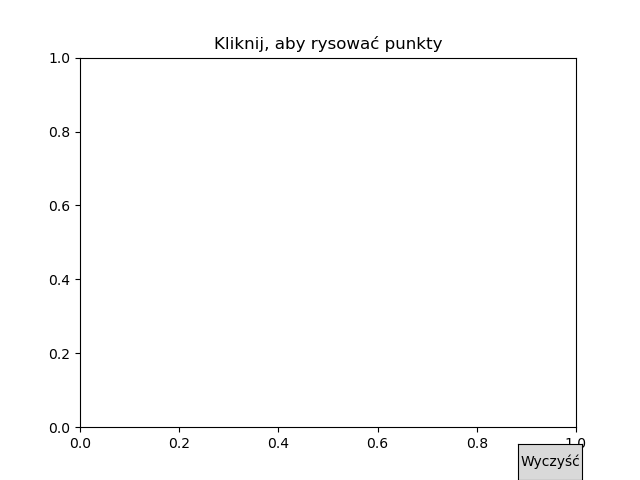

In [13]:
polygon = PolygonDrawer()

### Algorytm dziel i rządź - wersja z wizualizacją algorytmu

In [14]:
def divide_points_visual(points, first, last, visualizer, active_hulls):
    if last - first < 3:
        hull = set_hull(points, first, last)
        active_hulls.append(hull)
        visualizer.add_frame(points, active_hulls.copy(), [], [], None)
        return hull

    mid = (first + last) // 2

    visualizer.add_frame(points, active_hulls.copy(), [], [], None)

    left_hull = divide_points_visual(points, first, mid, visualizer, active_hulls)
    right_hull = divide_points_visual(points, mid + 1, last, visualizer, active_hulls)

    active_hulls.remove(left_hull)
    active_hulls.remove(right_hull)
    final_hull = merge_hulls(left_hull, right_hull)
    active_hulls.append(final_hull)

    visualizer.add_frame( points, active_hulls.copy(), [], [Segment(p1, p2) for p1, p2 in zip(final_hull, final_hull[1:] + final_hull[:1])], None)
    return final_hull


def divide_and_conquer_visual(points):
    visualizer = ConvexHullVisualizer()
    sorted_points = sorted(points, key=lambda point: (point.x, point.y))

    active_hulls = []
    visualizer.add_frame(sorted_points, [], [], [], None)

    divide_points_visual(sorted_points, 0, len(sorted_points) - 1, visualizer, active_hulls)
    display(visualizer.create_animation())


Wizualizacja algorytmu dziel i rządź

In [15]:
divide_and_conquer_visual(polygon.points)